In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
path="../temp"
folder=os.listdir(path)

In [3]:
df=[]
for i in folder:
    path1=os.path.join(path,i)
    data=pd.read_csv(path1)
    df.append(data)    

df

[    Unnamed: 0  YearsExperience    Salary
 0            0              1.2   39344.0
 1            1              1.4   46206.0
 2            2              1.6   37732.0
 3            3              2.1   43526.0
 4            4              2.3   39892.0
 5            5              3.0   56643.0
 6            6              3.1   60151.0
 7            7              3.3   54446.0
 8            8              3.3   64446.0
 9            9              3.8   57190.0
 10          10              4.0   63219.0
 11          11              4.1   55795.0
 12          12              4.1   56958.0
 13          13              4.2   57082.0
 14          14              4.6   61112.0
 15          15              5.0   67939.0
 16          16              5.2   66030.0
 17          17              5.4   83089.0
 18          18              6.0   81364.0
 19          19              6.1   93941.0
 20          20              6.9   91739.0
 21          21              7.2   98274.0
 22        

In [4]:
df[1]

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [5]:
target="Salary"

In [6]:
df[0].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 848.0 bytes


In [7]:
df[0].describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [ ]:
import pandas as pd
import numpy as np

def smart_remove_unnamed(
    df: pd.DataFrame,
    empty_threshold: float = 0.95,
    info_threshold: float = 0.2,
    aggressive: bool = False
):
    df = df.copy()

    dropped_cols = []
    flagged_cols = []

    n = len(df)

    def is_index_like(series):
        if not pd.api.types.is_numeric_dtype(series):
            return False
        expected = np.arange(n)
        return np.array_equal(series.fillna(-999).values, expected)

    def is_mostly_empty(series):
        return series.isna().mean() >= empty_threshold

    def info_score(series):
        non_null_ratio = 1 - series.isna().mean()
        unique_ratio = series.nunique(dropna=True) / max(len(series.dropna()), 1)
        return 0.7 * non_null_ratio + 0.3 * unique_ratio

    for col in df.columns:

        if "unnamed" in str(col).lower():

            series = df[col]

            index_like = is_index_like(series)
            empty_like = is_mostly_empty(series)
            score = info_score(series)

            # HIGH confidence garbage
            if index_like or empty_like or score < info_threshold:
                dropped_cols.append(col)

            # MEDIUM suspicious
            else:
                if aggressive:
                    dropped_cols.append(col)
                else:
                    flagged_cols.append(col)

    df = df.drop(columns=dropped_cols, errors="ignore")

    return df, dropped_cols


In [9]:
df[0],dropped,flagged=smart_remove_unnamed(df[0])
df[1],dropped1,flagged1=smart_remove_unnamed(df[1])


In [10]:
df[0].head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [11]:
df[1].head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [12]:
dropped1

[]

In [13]:
df[1]

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


# EDA

In [14]:
df[1].shape

(10000, 6)

In [15]:
df[1].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [16]:
df[1].describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [17]:
df[1].columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [18]:
import pandas as pd
import numpy as np

def auto_detect_feature_types(df, cat_unique_ratio=0.05, text_avg_len=30):
    """
    Automatically detect feature types: numeric, categorical, datetime, text
    """

    feature_types = {
        "numeric": [],
        "categorical": [],
        "datetime": [],
        "text": [],
        "unknown": []
    }

    n_rows = len(df)

    for col in df.columns:

        series = df[col]
        non_null = series.dropna()

        if len(non_null) == 0:
            feature_types["unknown"].append(col)
            continue

        # ===== NUMERIC CHECK =====
        if pd.api.types.is_numeric_dtype(series):
            feature_types["numeric"].append(col)
            continue

        # Try numeric conversion
        try:
            converted = pd.to_numeric(non_null, errors="raise")
            feature_types["numeric"].append(col)
            continue
        except:
            pass

        # ===== DATETIME CHECK =====
        if pd.api.types.is_datetime64_any_dtype(series):
            feature_types["datetime"].append(col)
            continue

        try:
            converted = pd.to_datetime(non_null, errors="raise")
            feature_types["datetime"].append(col)
            continue
        except:
            pass

        # ===== CATEGORICAL vs TEXT =====
        unique_ratio = non_null.nunique() / len(non_null)

        # Average text length
        avg_len = non_null.astype(str).str.len().mean()

        if unique_ratio < cat_unique_ratio:
            feature_types["categorical"].append(col)

        elif avg_len > text_avg_len:
            feature_types["text"].append(col)

        else:
            feature_types["categorical"].append(col)

    return feature_types



In [19]:
types=auto_detect_feature_types(df[1])

C:\Users\manth\AppData\Local\Temp\ipykernel_4752\4229622001.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(non_null, errors="raise")


In [20]:
df[1].head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [21]:
types['categorical']

['Extracurricular Activities']

In [22]:
def drop_or_not(df):
    if df.duplicated().sum()>((5/100)*len(df)):
        return False
    else:
        return True

In [23]:
def drop_duplicates(df):
    return df.drop_duplicates()

In [24]:
drop_or_not(df[1])

True

In [25]:
df[1]=drop_duplicates(df[1])

## Univariate Analysis

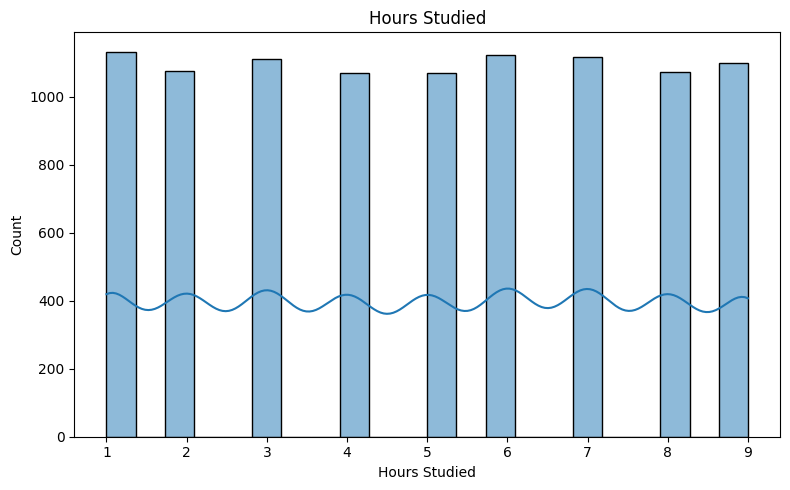

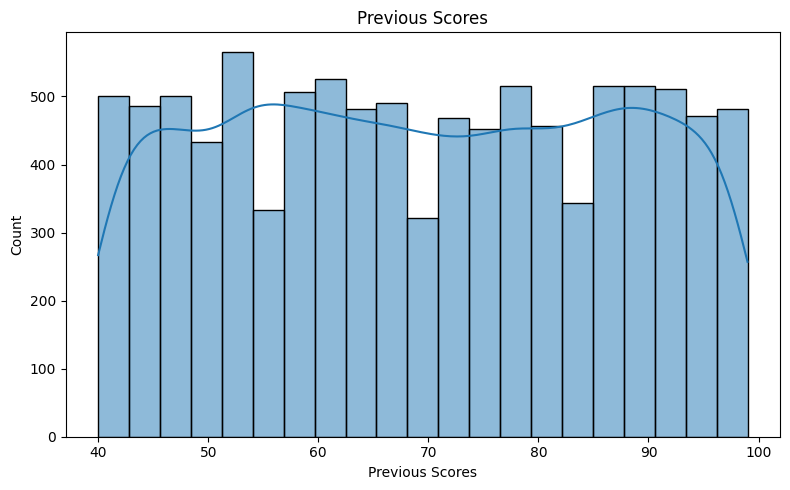

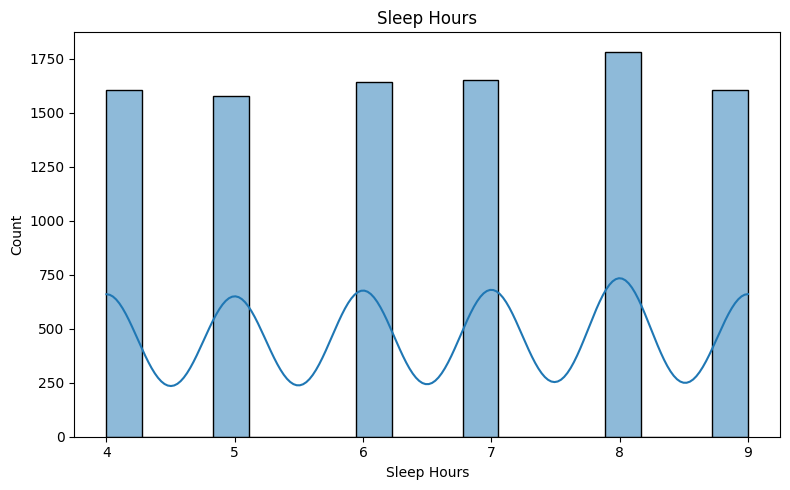

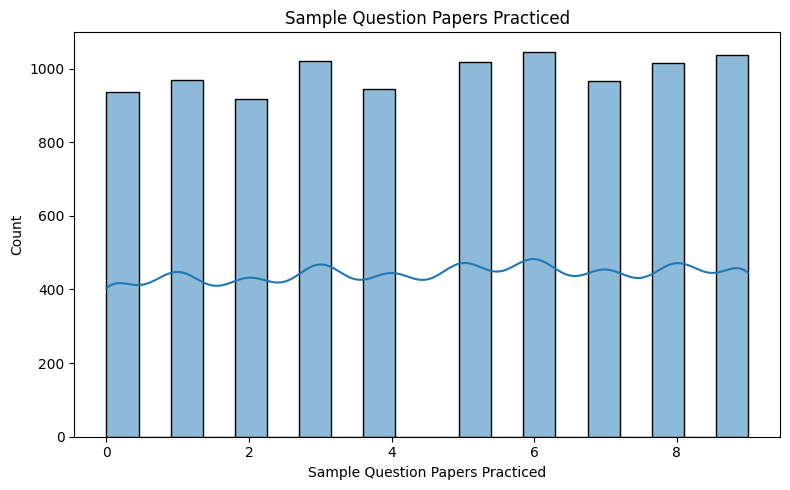

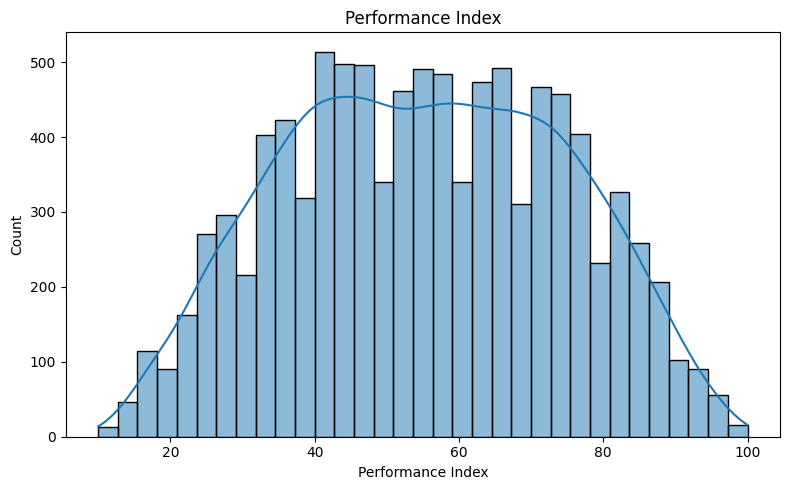

In [26]:

        
for i in types['numeric']:
    plt.figure(figsize=(8,5))
    sns.histplot(df[1][i], kde=True)
    plt.title(i)
    plt.tight_layout()
    plt.show()



In [31]:
import json

def stats_numeric(df,col):
    data={
        "Mean":df[col].mean(),
        "Median":df[col].median(),
        "Std":df[col].std(),
        "Variance":df[col].var(),
        "Skewness":df[col].skew(),
        "Kurtosis":df[col].kurt(),
        "Min":df[col].min(),
        "Max":df[col].max(),
        "25%":df[col].quantile(0.25),
        "50%":df[col].quantile(0.50),
        "75%":df[col].quantile(0.75)
    }
    return data
    

In [32]:
stats=[]

for i in types['numeric']:
    d=stats_numeric(df[1],i)
    stats.append(d)

In [33]:
stats

[{'Mean': np.float64(4.99209966575509),
  'Median': np.float64(5.0),
  'Std': np.float64(2.589081138944193),
  'Variance': np.float64(6.703341144036558),
  'Skewness': np.float64(-0.0033483737916364534),
  'Kurtosis': np.float64(-1.2337699833952724),
  'Min': np.int64(1),
  'Max': np.int64(9),
  '25%': np.float64(3.0),
  '50%': np.float64(5.0),
  '75%': np.float64(7.0)},
 {'Mean': np.float64(69.44110199534083),
  'Median': np.float64(69.0),
  'Std': np.float64(17.32560125228179),
  'Variance': np.float64(300.1764587530683),
  'Skewness': np.float64(0.0055813419610842956),
  'Kurtosis': np.float64(-1.2116826321592524),
  'Min': np.int64(40),
  'Max': np.int64(99),
  '25%': np.float64(54.0),
  '50%': np.float64(69.0),
  '75%': np.float64(85.0)},
 {'Mean': np.float64(6.531651980147878),
  'Median': np.float64(7.0),
  'Std': np.float64(1.6976828627670126),
  'Variance': np.float64(2.8821271025327992),
  'Skewness': np.float64(-0.04134960099660273),
  'Kurtosis': np.float64(-1.2590965175758

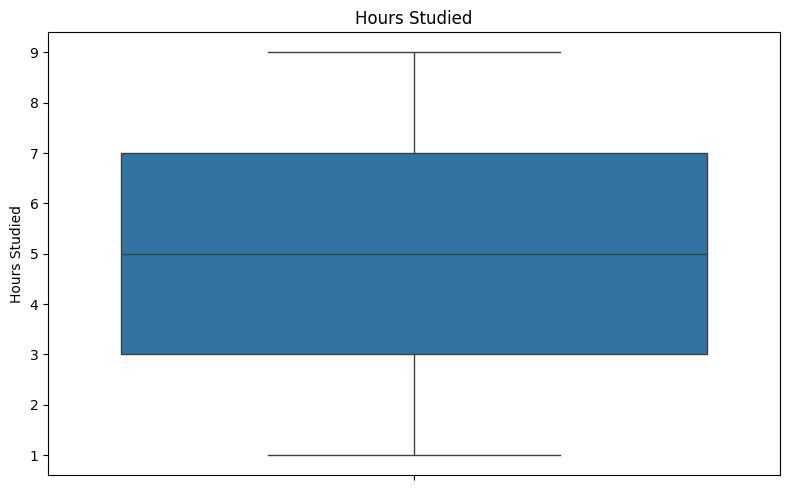

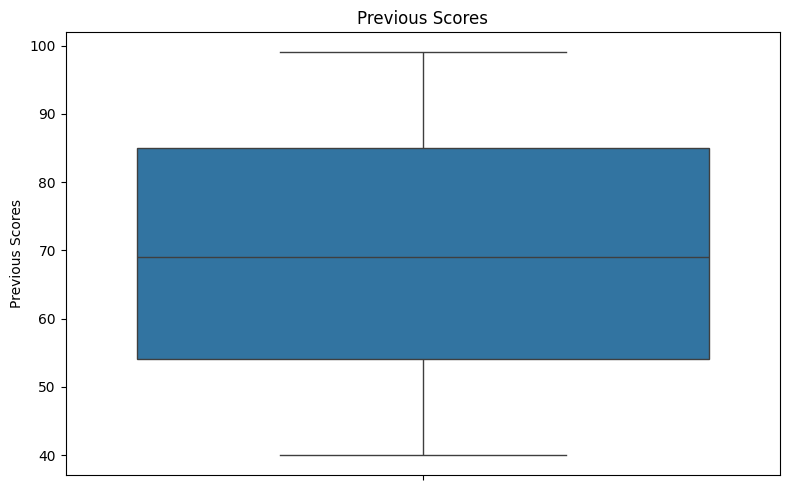

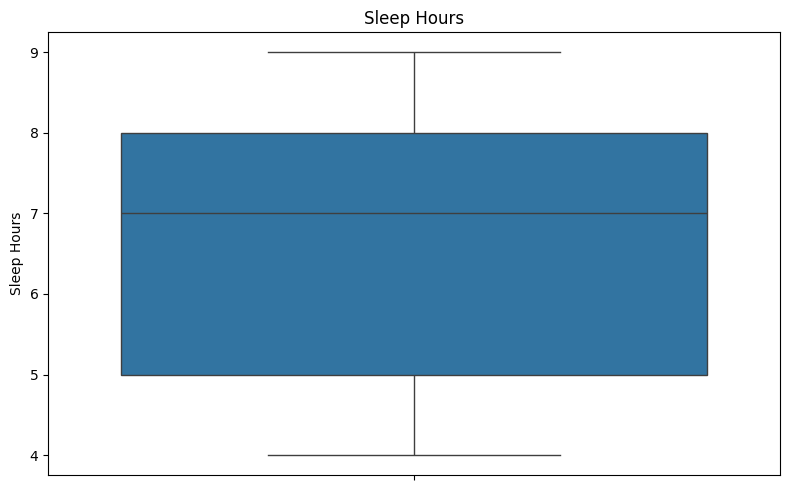

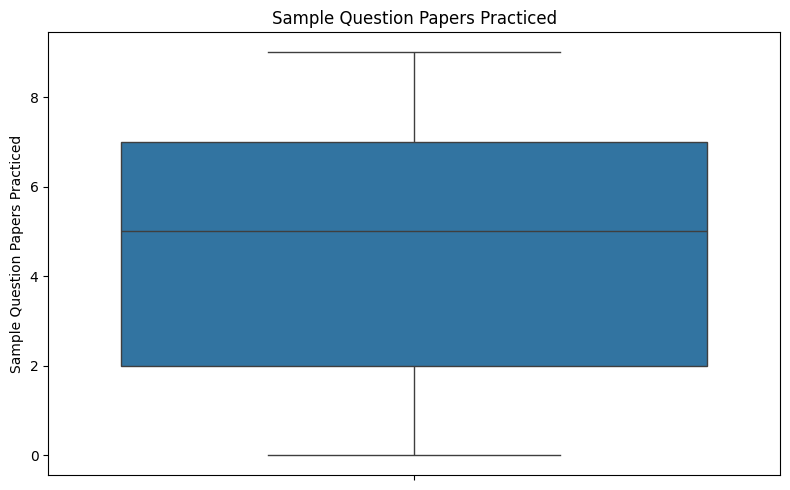

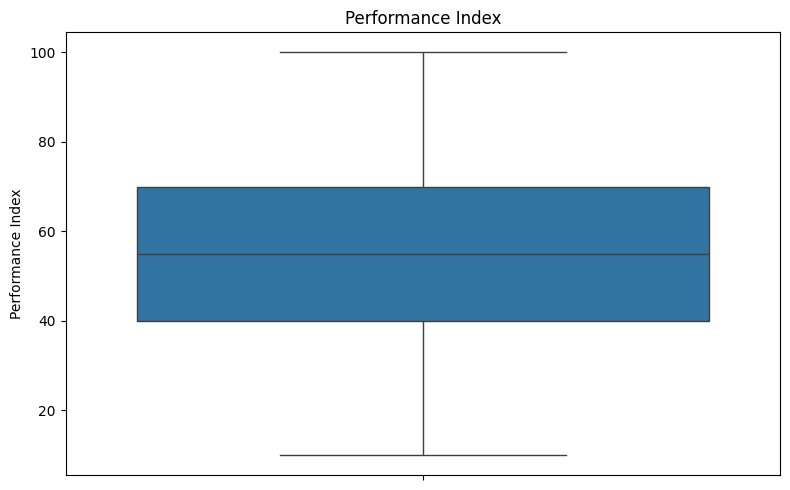

In [28]:
        
for i in types['numeric']:
    plt.figure(figsize=(8,5))
    sns.boxplot(df[1][i],)
    plt.title(i)
    plt.tight_layout()
    plt.show()


In [29]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')

In [54]:
def stats_categorical(df,col):
    vc={}
    for i,j in zip(df[col].value_counts().index,range(len(df[col].value_counts().index))):
        vc[i]=df[col].value_counts()[j]
        
    data={
        "Unique Count":df[col].nunique(),
        "Top Category":df[col].mode()[0],
        "Frequency Distribution":vc
    }
    return data

In [55]:
df[1][types['categorical'][0]].value_counts()[0]

C:\Users\manth\AppData\Local\Temp\ipykernel_4752\2792255176.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df[1][types['categorical'][0]].value_counts()[0]


np.int64(4986)

In [56]:
stats=[]

for i in types['categorical']:
    d=stats_categorical(df[1],i)
    stats.append(d)

C:\Users\manth\AppData\Local\Temp\ipykernel_4752\3488578068.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  vc[i]=df[col].value_counts()[j]
C:\Users\manth\AppData\Local\Temp\ipykernel_4752\3488578068.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  vc[i]=df[col].value_counts()[j]


In [57]:
stats[0]

{'Unique Count': 2,
 'Top Category': 'No',
 'Frequency Distribution': {'No': np.int64(4986), 'Yes': np.int64(4887)}}

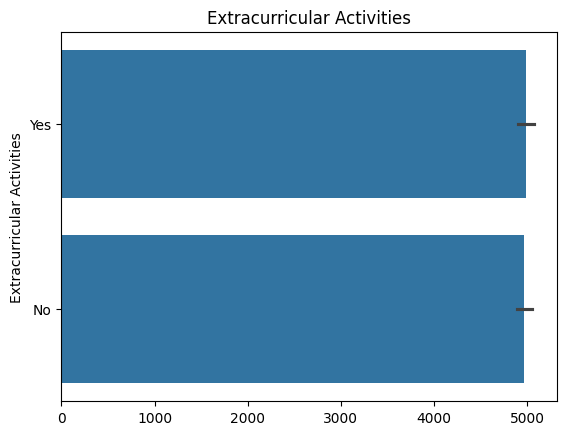

In [61]:
for i in types['categorical']:
    plt.Figure(figsize=(8,5))
    sns.barplot(df[1][i])
    plt.title(i)
    plt.show()
    